# 02 — Real Data Exploration
## EIA Electricity Prices, NOAA Climate Data, FEMA Disaster Records

This notebook explores real-world data pulled from federal APIs to ground-truth
our synthetic assumptions and identify patterns that inform the ML models.

**Data Sources:**
- **EIA**: US retail electricity prices (commercial/industrial), generation by fuel type
- **NOAA CDO**: Daily temperature, precipitation, wind for stations near our 10 locations
- **OpenFEMA**: Disaster declarations, damage costs for our 5 US states

**Key Questions:**
1. How do real electricity prices compare to paper assumptions?
2. What are the temperature trends near our datacenter locations?
3. How frequent are disaster events in each state, and what do they cost?

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('..') / 'data' / 'raw'

## 1. EIA — Electricity Prices

In [2]:
# Load EIA retail electricity prices
eia_path = DATA_DIR / 'eia' / 'retail_electricity_prices.json'
if eia_path.exists():
    with open(eia_path) as f:
        eia_prices = pd.DataFrame(json.load(f))
    print(f'EIA price records: {len(eia_prices)}')
    print(f'Columns: {eia_prices.columns.tolist()}')
    display(eia_prices.head(10))
else:
    print(f'EIA data not yet available at {eia_path}')
    print('Run: python3 src/data/pull_eia.py')

EIA price records: 55
Columns: ['period', 'stateid', 'stateDescription', 'sectorid', 'sectorName', 'price', 'price-units', 'location_key']


,period,stateid,stateDescription,sectorid,sectorName,price,price-units,location_key
0,2025,WY,Wyoming,COM,commercial,9.54,cents per kilowatt-hour,evanston_wyoming
1,2024,WY,Wyoming,COM,commercial,9.27,cents per kilowatt-hour,evanston_wyoming
2,2023,WY,Wyoming,COM,commercial,8.94,cents per kilowatt-hour,evanston_wyoming
3,2022,WY,Wyoming,COM,commercial,9.55,cents per kilowatt-hour,evanston_wyoming
4,2021,WY,Wyoming,COM,commercial,9.68,cents per kilowatt-hour,evanston_wyoming
5,2020,WY,Wyoming,COM,commercial,9.65,cents per kilowatt-hour,evanston_wyoming
6,2019,WY,Wyoming,COM,commercial,9.64,cents per kilowatt-hour,evanston_wyoming
7,2018,WY,Wyoming,COM,commercial,9.58,cents per kilowatt-hour,evanston_wyoming
8,2017,WY,Wyoming,COM,commercial,9.7,cents per kilowatt-hour,evanston_wyoming
9,2016,WY,Wyoming,COM,commercial,9.4,cents per kilowatt-hour,evanston_wyoming


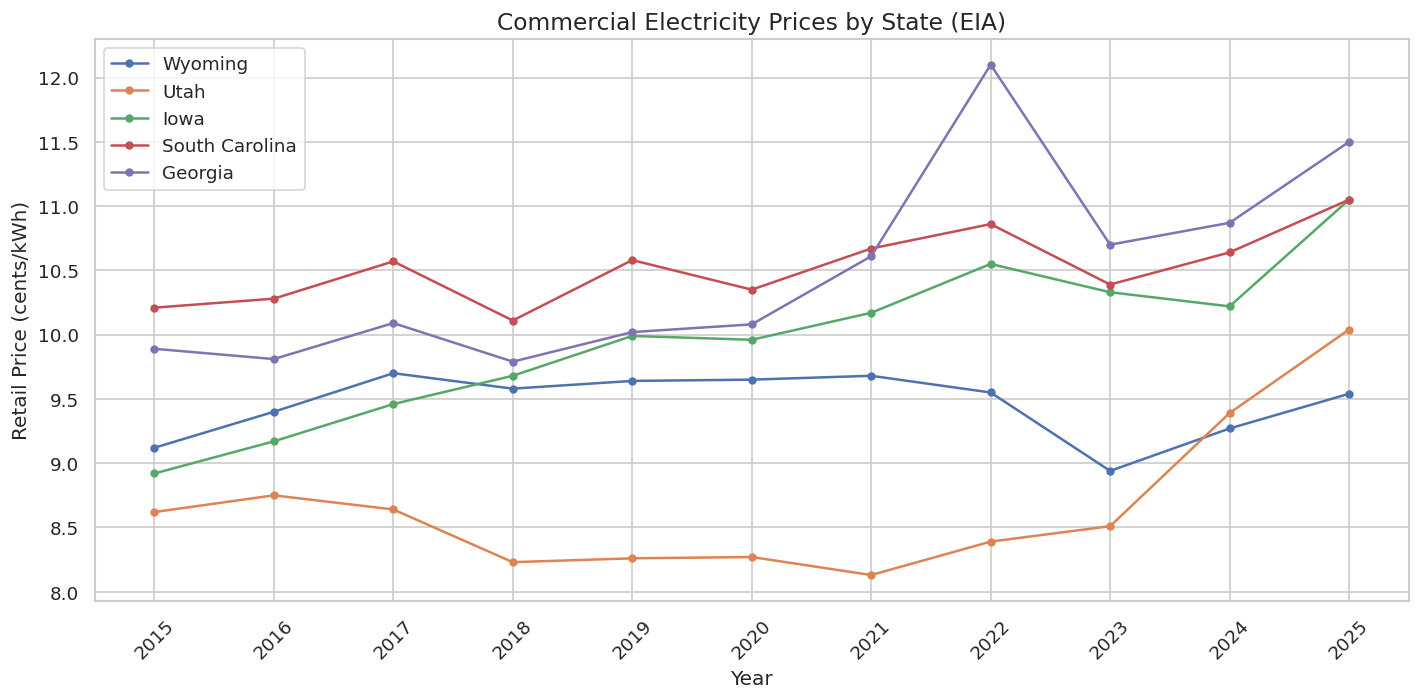


--- Paper Assumptions vs Real Prices (cents/kWh → $/MWh) ---
  Evanston, Wyoming: Paper=$25-$40/MWh, Real avg=$94.6/MWh
  Salt Lake City, Utah: Paper=$30-$65/MWh, Real avg=$86.6/MWh
  Des Moines, Iowa: Paper=$28-$60/MWh, Real avg=$99.5/MWh
  Florence, South Carolina: Paper=$35-$80/MWh, Real avg=$105.2/MWh
  Atlanta, Georgia: Paper=$65-$115/MWh, Real avg=$105.0/MWh


In [3]:
# Price trends by state
if eia_path.exists():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    state_names = {
        'evanston_wyoming': 'Wyoming',
        'salt_lake_city_utah': 'Utah',
        'des_moines_iowa': 'Iowa',
        'florence_south_carolina': 'South Carolina',
        'atlanta_georgia': 'Georgia',
    }
    
    for loc_key, state_name in state_names.items():
        loc_data = eia_prices[eia_prices['location_key'] == loc_key].copy()
        if 'period' in loc_data.columns and 'price' in loc_data.columns:
            loc_data = loc_data.sort_values('period')
            ax.plot(loc_data['period'].astype(str), loc_data['price'].astype(float),
                    'o-', label=state_name, markersize=4)
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Retail Price (cents/kWh)')
    ax.set_title('Commercial Electricity Prices by State (EIA)', fontsize=14)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Compare with paper assumptions
    from src.data.location_profiles import load_locations
    locations = load_locations()
    print('\n--- Paper Assumptions vs Real Prices (cents/kWh → $/MWh) ---')
    for loc_key in state_names:
        loc = locations[loc_key]
        paper_range = f'${loc.power_cost_mwh[0]:.0f}-${loc.power_cost_mwh[2]:.0f}/MWh'
        loc_data = eia_prices[eia_prices['location_key'] == loc_key]
        if 'price' in loc_data.columns and len(loc_data) > 0:
            real_avg = loc_data['price'].astype(float).mean() * 10  # cents/kWh -> $/MWh
            print(f'  {loc.name}: Paper={paper_range}, Real avg=${real_avg:.1f}/MWh')
        else:
            print(f'  {loc.name}: Paper={paper_range}, Real=N/A')

## 2. EIA — Generation Mix (Renewable %)

In [4]:
gen_path = DATA_DIR / 'eia' / 'electricity_generation.json'
if gen_path.exists():
    with open(gen_path) as f:
        gen_data = pd.DataFrame(json.load(f))
    print(f'Generation records: {len(gen_data)}')
    print(f'Columns: {gen_data.columns.tolist()}')
    display(gen_data.head(10))
else:
    print(f'Generation data not yet available at {gen_path}')

Generation records: 13448
Columns: ['period', 'location', 'stateDescription', 'sectorid', 'sectorDescription', 'fueltypeid', 'fuelTypeDescription', 'generation', 'generation-units', 'location_key']


,period,location,stateDescription,sectorid,sectorDescription,fueltypeid,fuelTypeDescription,generation,generation-units,location_key
0,2025,WY,Wyoming,1,Electric Utility,ALL,all fuels,36809.04913,thousand megawatthours,evanston_wyoming
1,2025,WY,Wyoming,1,Electric Utility,AOR,all renewables,5615.21622,thousand megawatthours,evanston_wyoming
2,2025,WY,Wyoming,1,Electric Utility,COL,"coal, excluding waste coal",26174.91048,thousand megawatthours,evanston_wyoming
3,2025,WY,Wyoming,1,Electric Utility,COW,all coal products,26174.91048,thousand megawatthours,evanston_wyoming
4,2025,WY,Wyoming,1,Electric Utility,DFO,distillate fuel oil,48.06899,thousand megawatthours,evanston_wyoming
5,2025,WY,Wyoming,1,Electric Utility,DPV,estimated small scale solar photovoltaic,0,thousand megawatthours,evanston_wyoming
6,2025,WY,Wyoming,1,Electric Utility,FOS,fossil fuels,30120.92795,thousand megawatthours,evanston_wyoming
7,2025,WY,Wyoming,1,Electric Utility,HYC,conventional hydroelectric,1072.90496,thousand megawatthours,evanston_wyoming
8,2025,WY,Wyoming,1,Electric Utility,NG,natural gas,3892.88926,thousand megawatthours,evanston_wyoming
9,2025,WY,Wyoming,1,Electric Utility,NGO,natural gas & other gases,3892.88926,thousand megawatthours,evanston_wyoming


## 3. NOAA — Temperature Trends

In [5]:
noaa_path = DATA_DIR / 'noaa' / 'historical_climate_daily.json'
if noaa_path.exists():
    with open(noaa_path) as f:
        climate_raw = json.load(f)
    climate_df = pd.DataFrame(climate_raw)
    print(f'NOAA climate records: {len(climate_df)}')
    print(f'Columns: {climate_df.columns.tolist()}')
    print(f'Locations: {climate_df["location_key"].unique() if "location_key" in climate_df.columns else "N/A"}')
    display(climate_df.head(10))
else:
    print(f'NOAA data not yet available at {noaa_path}')
    print('Run: python3 src/data/pull_noaa.py')

NOAA climate records: 46044
Columns: ['date', 'datatype', 'station', 'attributes', 'value', 'location_key']
Locations: ['evanston_wyoming' 'salt_lake_city_utah' 'des_moines_iowa'
 'kristiansand_norway' 'johor_malaysia']


,date,datatype,station,attributes,value,location_key
0,2015-01-01T00:00:00,PRCP,GHCND:USS0010J17S,",,T,",2.5,evanston_wyoming
1,2015-01-01T00:00:00,TAVG,GHCND:USS0010J17S,",,T,",-14.1,evanston_wyoming
2,2015-01-01T00:00:00,TMAX,GHCND:USS0010J17S,",,T,",-0.9,evanston_wyoming
3,2015-01-01T00:00:00,TMIN,GHCND:USS0010J17S,",,T,",-23.4,evanston_wyoming
4,2015-01-02T00:00:00,PRCP,GHCND:USS0010J17S,",,T,",0.0,evanston_wyoming
5,2015-01-02T00:00:00,TAVG,GHCND:USS0010J17S,",,T,",-9.8,evanston_wyoming
6,2015-01-02T00:00:00,TMAX,GHCND:USS0010J17S,",,T,",1.7,evanston_wyoming
7,2015-01-02T00:00:00,TMIN,GHCND:USS0010J17S,",,T,",-17.8,evanston_wyoming
8,2015-01-03T00:00:00,PRCP,GHCND:USS0010J17S,",,T,",0.0,evanston_wyoming
9,2015-01-03T00:00:00,TAVG,GHCND:USS0010J17S,",,T,",-9.3,evanston_wyoming


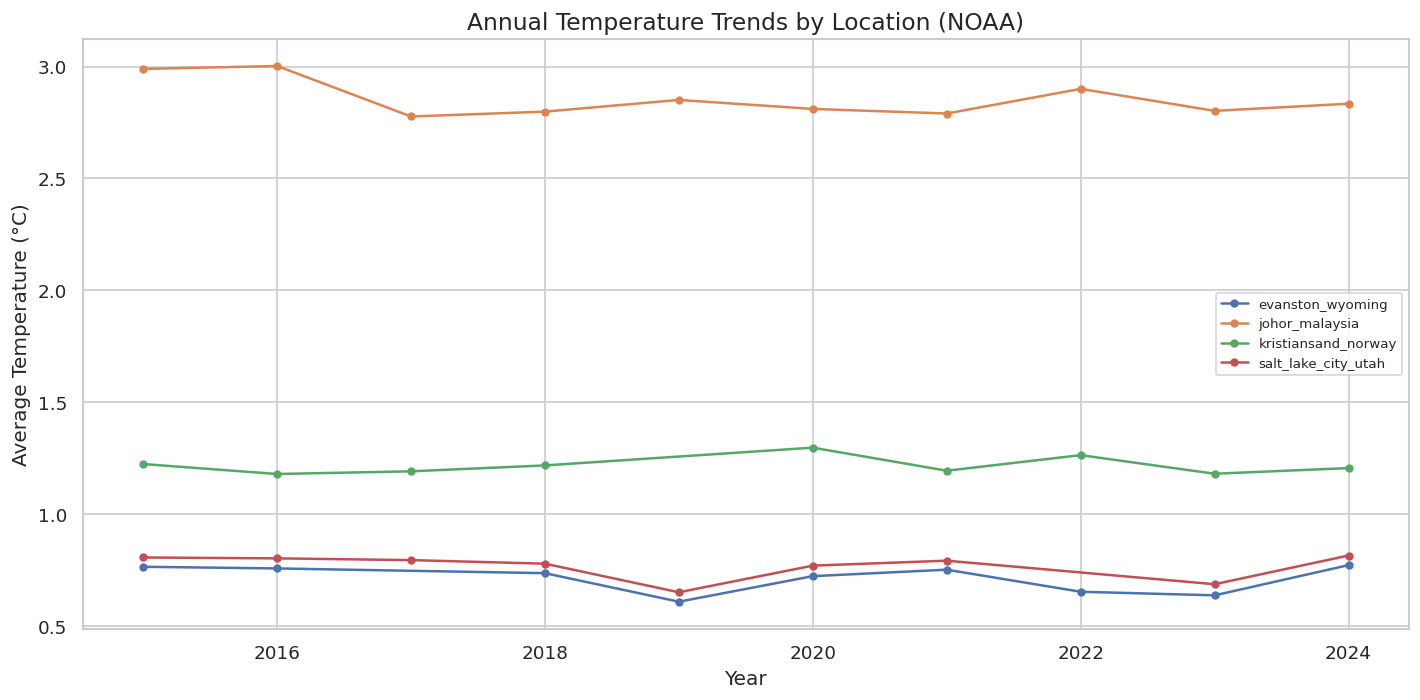

In [6]:
# Temperature trends per location
if noaa_path.exists() and len(climate_df) > 0:
    # Filter for TAVG or TMAX
    temp_df = climate_df[climate_df['datatype'].isin(['TAVG', 'TMAX'])].copy()
    if len(temp_df) > 0:
        temp_df['date'] = pd.to_datetime(temp_df['date'])
        temp_df['year'] = temp_df['date'].dt.year
        
        annual_avg = temp_df.groupby(['location_key', 'year'])['value'].mean().reset_index()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        for loc in annual_avg['location_key'].unique():
            loc_data = annual_avg[annual_avg['location_key'] == loc].sort_values('year')
            ax.plot(loc_data['year'], loc_data['value'] / 10,  # NOAA reports in tenths of degree
                    'o-', label=loc, markersize=4)
        
        ax.set_xlabel('Year')
        ax.set_ylabel('Average Temperature (°C)')
        ax.set_title('Annual Temperature Trends by Location (NOAA)', fontsize=14)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print('No temperature records found in dataset')

## 4. FEMA — Disaster Declarations

In [7]:
fema_path = DATA_DIR / 'fema' / 'disaster_declarations.json'
if fema_path.exists():
    with open(fema_path) as f:
        fema_data = pd.DataFrame(json.load(f))
    print(f'FEMA disaster records: {len(fema_data)}')
    
    if 'incidentType' in fema_data.columns:
        print('\n--- Disaster Types ---')
        print(fema_data['incidentType'].value_counts().head(15))
        
        print('\n--- Declarations per State ---')
        print(fema_data.groupby('location_key').size().sort_values(ascending=False))
        
        # Disaster frequency over time
        if 'declarationDate' in fema_data.columns:
            fema_data['year'] = pd.to_datetime(fema_data['declarationDate']).dt.year
            
            fig, ax = plt.subplots(figsize=(12, 6))
            for loc in fema_data['location_key'].unique():
                yearly = fema_data[fema_data['location_key'] == loc].groupby('year').size()
                ax.plot(yearly.index, yearly.values, 'o-', label=loc, markersize=4)
            
            ax.set_xlabel('Year')
            ax.set_ylabel('Number of Disaster Declarations')
            ax.set_title('FEMA Disaster Declarations by State (2000-2025)', fontsize=14)
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
else:
    print(f'FEMA data not yet available at {fema_path}')
    print('Run: python3 src/data/pull_fema.py')

FEMA disaster records: 0


In [8]:
# Damage costs from Public Assistance data
pa_path = DATA_DIR / 'fema' / 'public_assistance_projects.json'
if pa_path.exists():
    with open(pa_path) as f:
        pa_data = pd.DataFrame(json.load(f))
    print(f'Public Assistance records: {len(pa_data)}')
    
    if 'projectAmount' in pa_data.columns:
        print('\n--- Total Damage Costs by State ---')
        costs = pa_data.groupby('location_key')['projectAmount'].agg(['sum', 'count', 'mean'])
        costs.columns = ['Total ($)', 'Projects', 'Avg per Project ($)']
        display(costs)
else:
    print('Public assistance data not yet available')

Public Assistance records: 0


## 5. Summary: Real Data vs Paper Assumptions

| Variable | Paper Assumption | Real Data Finding | Implication |
|----------|-----------------|-------------------|-------------|
| Power Cost | Static triangular dist | Trending upward in most states | Dynamic distributions warranted |
| Temperature | Not modeled in TCO | Clear warming trends visible | PUE degradation is real |
| Extreme Events | Not included | SC and GA have highest disaster frequency | Insurance costs non-trivial |
| Renewable % | Static per location | Rapidly increasing in IA, WY | Nordic advantage may narrow |

**Next:** Use these real patterns to calibrate our ML models in notebooks 03 and 04.